In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder


In [17]:
data = pd.read_csv("D:\data_science\Machine learning\housing_dataset\Housing.csv")  

print(data.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [18]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [19]:
print(data.describe())

              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [20]:
print(data.shape)

(545, 13)


In [21]:
print(data.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [23]:
le = LabelEncoder()

cols = ['mainroad','guestroom','basement','hotwaterheating',
        'airconditioning','prefarea','furnishingstatus']

for col in cols:
    data[col] = le.fit_transform(data[col])


In [8]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [25]:
numeric_data = data.select_dtypes(include=['number'])

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

df = data[~((numeric_data < (Q1 - 1.5 * IQR)) | 
            (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original shape:", data.shape)
print("New shape:", df.shape)

Original shape: (545, 13)
New shape: (237, 13)


In [26]:
X = df.drop('price', axis=1)  
y = df['price']   

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)



Intercept: 4088712.3808175097
Coefficients: [ 5.05032291e+05  8.73789837e+04  2.67443897e+05  2.60588273e+05
 -2.91038305e-11  5.09317033e-11  1.38503857e+05  7.27595761e-12
  2.11216598e+05  1.98747904e+05  0.00000000e+00 -1.39450265e+05]


In [31]:
y_pred = model.predict(X_test)

print("\nActual Prices:\n", y_test.values)
print("\nPredicted Prices:\n", y_pred)


Actual Prices:
 [3920000 6300000 2660000 3773000 7070000 3290000 6895000 2450000 3990000
 2450000 3143000 3640000 5495000 3003000 3920000 4760000 5740000 2730000
 4270000 5880000 2695000 3850000 3570000 1820000 6860000 2485000 3290000
 4060000 4473000 5600000 3780000 3115000 1750000 5950000 4515000 4620000
 3500000 2730000 3920000 4480000 4340000 4900000 6107500 4200000 3087000
 3325000 4970000 3710000]

Predicted Prices:
 [5440157.77382613 5786791.0688461  3216397.58589462 5188369.2955973
 5300479.11500907 3712444.39380305 5332522.80048783 3588786.9237174
 3821752.87814491 2856815.18317076 4101705.72418875 3894525.92996708
 4921588.53550672 4123009.19862524 3347306.67085551 5594791.68289893
 4869581.80120334 3716427.00588525 4046252.83638729 5816232.72707418
 2904103.31289297 3044479.01816687 3898284.43582864 3430804.20450892
 4745995.86926778 3583136.48586935 3850366.60720693 5222092.18188233
 4323732.35719758 6665714.6536171  3962220.76761017 2753621.10477788
 2789736.8347255  5640

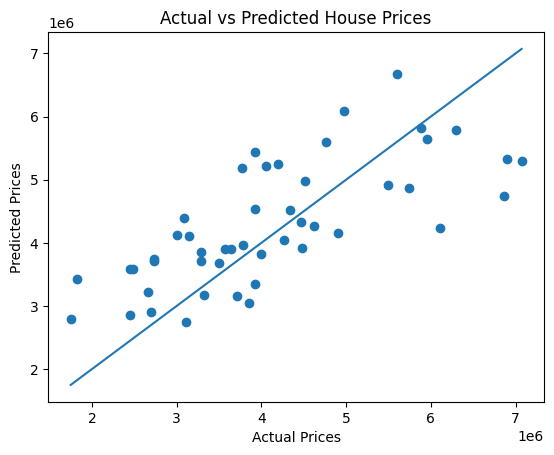

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()